ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

In this lab, we will apply practical preprocessing techniques step by step.

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [ ]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("train.csv")
df.head(10)

## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Sex` should be category
- `Embarked` should be category
- `Survived` should be bool

In [36]:
df.dtypes

PassengerId       int64
Survived           bool
Pclass            int64
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin               str
Embarked       category
dtype: object

We observe that some columns are stored as object type.  
`Sex`, `Embarked` and `Embarked` may not yet be in the correct format.
Incorrect data types can prevent proper calculations and time-based analysis.

### 2.2 Convert Incorrect Data Types
We will convert:
- `Sex` to category format
- `Embarked` to category format
- `Survivied` to bool format

In [37]:
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
df['Survived'] = df['Survived'].astype(bool)

df.dtypes

PassengerId       int64
Survived           bool
Pclass            int64
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin               str
Embarked       category
dtype: object

Now `Emabrked` is correctly stored as *category*.  
`embarked` is now category *(category)*.  
`survived` is now bool *(bool)*.  
This allows us to perform format change

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [38]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The output shows whether any column contains missing values.
If all values are zero, the dataset is complete.
If any column contains missing values, we must handle them.

Why?
In a perfect world, data arrives clean.   In reality, it’s usually "messy." Since our current Amount column is complete, we will manually inject some NaN (Not a Number) values to simulate a real-world scenario where data might have been lost during a transaction or skipped during entry.

In [39]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan
df_missing.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Amount         891
dtype: int64

Now the Amount as well as others columns contain missing values.

In [40]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (891, 12)
After removing some values:  (891, 13)


In [41]:
df_missing.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Amount
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,NaN
2,3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN
3,4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,NaN
4,5,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN
5,6,False,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,NaN
6,7,False,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,NaN
7,8,False,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,NaN
8,9,True,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,NaN
9,10,True,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,NaN


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [42]:
df_removed = df_missing.dropna()
df_removed.shape

(0, 13)

In [43]:
df_removed.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Amount         0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

The mean represents the average value.
It is commonly used for normally distributed data.

In [44]:
df_missing.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Amount
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,NaN
2,3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN
3,4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,NaN
4,5,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN
5,6,False,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,NaN
6,7,False,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,NaN
7,8,False,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,NaN
8,9,True,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,NaN
9,10,True,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,NaN


In [45]:
# 1. Ensure the column is numeric (Crucial!)
df_imputed_mean['Amount'] = pd.to_numeric(df_imputed_mean['Amount'], errors='coerce')

# 2. Calculate the mean and PRINT it to verify it's a number
mean_val = df_imputed_mean['Amount'].mean()
print(f"The calculated mean is: {mean_val}")

# 3. Fill and assign (Avoiding inplace=True for reliability)
df_imputed_mean['Amount'] = df_imputed_mean['Amount'].fillna(mean_val)

# 4. Check the results
print("\nFirst 7 rows of 'Amount':")# 1. Reset 'Amount' using the 'Fare' data so it's not all NaNs
df_missing['Amount'] = df['Fare'] 

# 2. Re-introduce the 6 artificial missing values for your demo
df_missing.loc[0:5, 'Amount'] = np.nan

# 3. Calculate the mean (Pandas will ignore the 6 NaNs and average the rest)
mean_val = df_missing['Amount'].mean()
print(f"The calculated mean is now: {mean_val:.2f}")

# 4. Fill the gaps using the real mean
df_missing['Amount'] = df_missing['Amount'].fillna(mean_val)

# 5. Check the result
print("\nFirst 7 rows after proper imputation:")
print(df_missing['Amount'].head(7))
print(df_imputed_mean['Amount'].head(7))

print("\nMissing values remaining:")
print(df_imputed_mean['Amount'].isna().sum())

The calculated mean is: 32.246386083052755

First 7 rows of 'Amount':
The calculated mean is now: 32.25

First 7 rows after proper imputation:
0    32.246195
1    32.246195
2    32.246195
3    32.246195
4    32.246195
5    32.246195
6    51.862500
Name: Amount, dtype: float64
0    32.25
1    32.25
2    32.25
3    32.25
4    32.25
5    32.25
6    51.86
Name: Amount, dtype: float64

Missing values remaining:
0


In [46]:
# 1. Ensure 'Amount' has data by pulling from 'Fare'
df_imputed_mean['Amount'] = df['Fare'].copy()

# 2. Introduce artificial missing values (first 6 rows)
df_imputed_mean.loc[0:5, 'Amount'] = np.nan

# 3. Calculate mean from the existing data
mean_val = df_imputed_mean['Amount'].mean()

# 4. Fill NaNs and overwrite the column (no inplace)
df_imputed_mean['Amount'] = df_imputed_mean['Amount'].fillna(mean_val)

# 5. Round for clean presentation
df_imputed_mean['Amount'] = df_imputed_mean['Amount'].round(2)

# --- VERIFY RESULTS ---
print("--- After Successful Imputation ---")
print(df_imputed_mean[['Amount']].head(7))
print(f"\nMissing values remaining: {df_imputed_mean['Amount'].isna().sum()}")

--- After Successful Imputation ---
   Amount
0   32.25
1   32.25
2   32.25
3   32.25
4   32.25
5   32.25
6   51.86

Missing values remaining: 0


Missing values are now replaced with the average revenue.
This preserves dataset size but may reduce variability.
Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation

The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [47]:
# 1. Create a copy to preserve original data
df_imputed_median = df_missing.copy()

# 2. Ensure 'Amount' has the 'Fare' data before introducing NaNs
df_imputed_median['Amount'] = df['Fare'].copy()
df_imputed_median.loc[0:5, 'Amount'] = np.nan

# 3. Calculate and apply the Median (Explicit assignment is safer than inplace=True)
median_value = df_imputed_median['Amount'].median()
df_imputed_median['Amount'] = df_imputed_median['Amount'].fillna(median_value)

# 4. Check for missing values
print(f"Median value used for imputation: {median_value}")
print(df_imputed_median['Amount'].isna().sum())

Median value used for imputation: 14.4542
0


In [48]:
df_imputed_median.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Amount
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,14.4542
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,14.4542
2,3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,14.4542
3,4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,14.4542
4,5,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,14.4542
5,6,False,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,14.4542
6,7,False,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,51.8625
7,8,False,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,21.0750
8,9,True,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,11.1333
9,10,True,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,30.0708


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using IQR method.


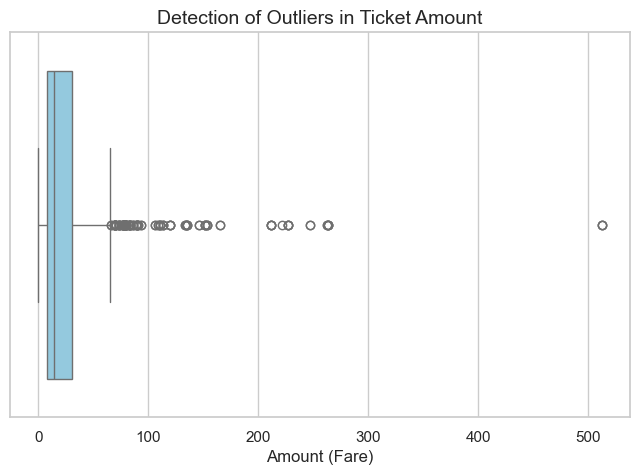

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
# Use the dataframe where we handled missing values
sns.boxplot(x=df_imputed_median['Amount'], color='skyblue')

# Adding labels that match the Titanic/Financial context
plt.title("Detection of Outliers in Ticket Amount", fontsize=14)
plt.xlabel("Amount (Fare)", fontsize=12)

plt.show()

Points outside the whiskers represent potential outliers.
These extreme revenue values may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [50]:
# 1. Calculate the Quartiles
Q1 = df_imputed_median['Amount'].quantile(0.25)
Q3 = df_imputed_median['Amount'].quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define the Outlier Bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 4. Filter the data to find the outliers
outliers = df_imputed_median[(df_imputed_median['Amount'] < lower) | (df_imputed_median['Amount'] > upper)]

# 5. Display the first 15 outliers found
print(f"Lower Bound: {lower:.2f}, Upper Bound: {upper:.2f}")
print(f"Total Outliers Found: {len(outliers)}")
outliers[['Name', 'Pclass', 'Amount']].head(15)

Lower Bound: -26.46, Upper Bound: 65.23
Total Outliers Found: 115


,Name,Pclass,Amount
27,"Fortune, Mr. Charles Alexander",1,263.0000
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",1,146.5208
34,"Meyer, Mr. Edgar Joseph",1,82.1708
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",1,76.7292
61,"Icard, Miss. Amelie",1,80.0000
62,"Harris, Mr. Henry Birkhardt",1,83.4750
72,"Hood, Mr. Ambrose Jr",2,73.5000
88,"Fortune, Miss. Mabel Helen",1,263.0000
102,"White, Mr. Richard Frasar",1,77.2875
118,"Baxter, Mr. Quigg Edmond",1,247.5208


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value transactions or potential data errors.

### Remove Outliers
We remove values outside the acceptable range.

In [51]:
# 1. Corrected filter: Ensure each condition is wrapped in parentheses
df_no_outliers = df_imputed_median[(df_imputed_median['Amount'] >= lower) & 
                                   (df_imputed_median['Amount'] <= upper)]

# 2. Compare the datasets
print("Original shape: ", df_imputed_median.shape)
print("After removing outliers: ", df_no_outliers.shape)

# 3. Calculate how many passengers were "dropped"
rows_dropped = df_imputed_median.shape[0] - df_no_outliers.shape[0]
print(f"Total outliers removed: {rows_dropped}")

Original shape:  (891, 13)
After removing outliers:  (776, 13)
Total outliers removed: 115


The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  
For example, in a sales dataset, a very large transaction might correspond to a bulk corporate order or a seasonal promotion.  

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.


In [52]:
# 1. Calculate the 5th and 95th percentiles
lower_cap = df_imputed_median['Amount'].quantile(0.05)
upper_cap = df_imputed_median['Amount'].quantile(0.95)

# 2. Create a copy to keep your experiments separate
df_capped = df_imputed_median.copy()

# 3. Use .clip() to cap values below the 5th and above the 95th percentiles
df_capped['Amount'] = df_capped['Amount'].clip(lower_cap, upper_cap)

# 4. Verify the results
print(f"Lower Cap (5th percentile): {lower_cap:.2f}")
print(f"Upper Cap (95th percentile): {upper_cap:.2f}")
print(f"New Maximum Amount: {df_capped['Amount'].max()}")
print(f"New Minimum Amount: {df_capped['Amount'].min()}")
print(f"Final Shape: {df_capped.shape}")

Lower Cap (5th percentile): 7.22
Upper Cap (95th percentile): 112.08
New Maximum Amount: 112.07915
New Minimum Amount: 7.225
Final Shape: (891, 13)


## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [56]:
# View the first 5 rows of our capped and cleaned data
# We use df_capped since that was our most recent 'best' version
print("--- Final Cleaned Data (Capped & Imputed) ---")
print(df_capped[['Amount', 'Fare', 'Pclass']].head())

--- Final Cleaned Data (Capped & Imputed) ---
    Amount     Fare  Pclass
0  14.4542   7.2500       3
1  14.4542  71.2833       1
2  14.4542   7.9250       3
3  14.4542  53.1000       1
4  14.4542   8.0500       3


In [55]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the scaler
scaler = MinMaxScaler()

# 2. Select valid numerical columns from your cleaned dataframe (df_capped)
# Let's use 'Amount' and 'Age' (after ensuring Age has no NaNs)
df_capped['Age'] = df_capped['Age'].fillna(df_capped['Age'].median())

cols_to_scale = ['Amount', 'Age']
df_scaled = df_capped[cols_to_scale].copy()

# 3. Fit and transform the data
# This converts values to a range between 0 and 1
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

# 4. Check the results
print("--- Scaled Features (Range: 0 to 1) ---")
print(df_scaled.head())

--- Scaled Features (Range: 0 to 1) ---
     Amount       Age
0  0.068945  0.271174
1  0.068945  0.472229
2  0.068945  0.321438
3  0.068945  0.434531
4  0.068945  0.434531


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one transaction originally had higher revenue than another, it will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation

This method keeps the shape of the distribution but rescales it around zero.

In [58]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Select numerical columns (ensure 'Age' has no NaNs first)
df_capped['Age'] = df_capped['Age'].fillna(df_capped['Age'].median())
cols_to_standardize = ['Amount', 'Age']

# 3. Create a copy and transform
df_standardized = df_capped[cols_to_standardize].copy()
df_standardized[cols_to_standardize] = scaler.fit_transform(df_standardized[cols_to_standardize])

# 4. View the result
print("--- Standardized Data (Mean ≈ 0, Std ≈ 1) ---")
print(df_standardized.head())

# Check the new mean and standard deviation
print(f"\nNew Mean for Amount: {df_standardized['Amount'].mean():.2f}")
print(f"New Std Dev for Amount: {df_standardized['Amount'].std():.2f}")

--- Standardized Data (Mean ≈ 0, Std ≈ 1) ---
     Amount       Age
0 -0.458903 -0.565736
1 -0.458903  0.663861
2 -0.458903 -0.258337
3 -0.458903  0.433312
4 -0.458903  0.433312

New Mean for Amount: -0.00
New Std Dev for Amount: 1.00


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

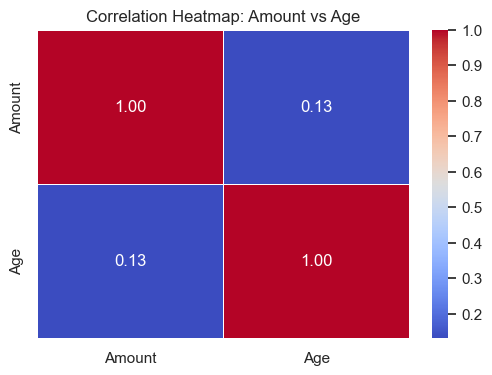

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select existing columns from your standardized dataframe
# We'll use 'Amount' and 'Age' (ensure they are in df_standardized)
plot_cols = ['Amount', 'Age']

plt.figure(figsize=(6, 4))

# 2. Calculate the correlation matrix
corr_matrix = df_standardized[plot_cols].corr()

# 3. Create the Heatmap
sns.heatmap(corr_matrix, 
            annot=True,      # Shows the numbers inside the boxes
            cmap="coolwarm", # Red for positive, Blue for negative
            fmt=".2f",       # Limits decimals to 2
            linewidths=0.5)

plt.title("Correlation Heatmap: Amount vs Age")
plt.show()

The heatmap shows the correlation between the numerical features:

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- The correlation between `Amount` and `Boxes Shipped` is approximately *-0.013*.

A correlation value close to 0 indicates that there is almost **NO linear** relationship between the two features.

This means that `Amount` and `Boxes Shipped` do not move together in a predictable linear pattern.

Since PCA is most useful when features are strongly correlated, 
the benefit of dimensionality reduction in this case may be limited.

Therefore, applying PCA here is mainly for demonstration purposes rather than necessity.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [ ]:
from sklearn.decomposition import PCA

X = df_standardized[['Amount', 'Boxes Shipped']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

For example:
- If PC1 explains 85% of the variance, it means that one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

In [ ]:
# # In addition to the heatmap, we can visualize the relationship between two features using a scatter plot. 
# # A scatter plot allows us to observe whether the features exhibit a linear pattern, meaning whether they increase or decrease together in a consistent way.


# plt.figure(figsize=(6,4))
# plt.scatter(df_standardized['Amount'], df_standardized['Boxes Shipped'])
# plt.xlabel("Amount (Standardized)")
# plt.ylabel("Boxes Shipped (Standardized)")
# plt.title("Scatter Plot: Amount vs Boxes Shipped")
# plt.show()

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one sales transaction.

The axes no longer represent the original features (Amount and Boxes Shipped).
Instead:

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures the direction of maximum variance in the data.
PC2 captures the second most important direction, perpendicular to PC1.

The spread of points along the horizontal direction indicates how much variation is captured by PC1.
If most of the spread appears horizontally, it suggests that PC1 captures most of the dataset's information.

This projection allows us to visualize high-dimensional data in a lower-dimensional space.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of lab 4.